# LIBRARY

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_curve, auc
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from sktime.transformations.panel.shapelet_transform import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from scikitplot.metrics import plot_roc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd
import gzip 
import pickle 
from collections import Counter
import matplotlib.pyplot as plt
import gzip
import pickle
import sys
import numpy as np
import warnings
import pandas as pd
from scipy.stats import levene
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", UserWarning)
from collections import Counter


In [3]:
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import matplotlib.pyplot as plt

def print_classification_results(best_model, X_test, y_test, model_name="Model"):
    """
    Print full classification results:
    - F1 score
    - Confusion matrix plot
    - ROC curve plot
    - Classification report
    - Confusion matrix breakdown
    """

    # ── Predictions ───────────────────────────────────────────────────────
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"{'='*60}")
    print(f"  Model       : {model_name}")
    print(f"  Test F1     : {test_f1:.4f}")
    print(f"{'='*60}")

    # ── Confusion matrix ──────────────────────────────────────────────────
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Results — {model_name}", fontsize=13, fontweight="bold")

    disp.plot(cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix")
    axes[0].grid(False)

    # ── ROC curve ─────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc     = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color="#7F77DD", linewidth=2,
                 label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve")
    axes[1].legend(loc="lower right")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    # ── Classification report ─────────────────────────────────────────────
    print(classification_report(
        y_test, y_pred,
        target_names=["Class 0", "Class 1"]
    ))

    # ── Confusion matrix breakdown ────────────────────────────────────────
    print(f"  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0, 0]}")
    print(f"    FP (false positives)   : {cm[0, 1]}")
    print(f"    FN (false negatives)   : {cm[1, 0]}")
    print(f"    TP (correct positives) : {cm[1, 1]}")
    print(f"    AUC                    : {roc_auc:.4f}")
    print(f"{'='*60}")

# DATAFRAMES

In [4]:
with gzip.open("../1.DATASET/CMI_timeseries_personalized.pkl.gz", "rb") as f:
	 CMI_timeseries_personalized = pickle.load(f)

In [5]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_personalized)}")

Number of time series: 4307


## Cleaning

In [6]:
df = CMI_timeseries_personalized[0].copy()
df.columns

Index(['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light',
       'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id',
       'sii_binary'],
      dtype='object')

In [7]:
cols_to_drop = ["battery_voltage", "timestamp", "quarter", "relative_date_PCIAT"]
data_clean   = [df.drop(columns=cols_to_drop, errors="ignore") for df in CMI_timeseries_personalized]

print(f"Columns remaining: {data_clean[0].columns.tolist()}")
print(f"Total subjects   : {len(data_clean)}")

Columns remaining: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'weekday', 'id', 'sii_binary']
Total subjects   : 4307


## id check

In [8]:
all_labels = [df["sii_binary"].iloc[0] for df in data_clean]
all_ids    = [df["id"].iloc[0]         for df in data_clean]

# Filter missing labels
valid_idx    = [i for i, label in enumerate(all_labels) if not pd.isna(label)]
valid_labels = np.array([all_labels[i] for i in valid_idx])
valid_ids    = np.array([all_ids[i]    for i in valid_idx])

print(f"Total datasets          : {len(data_clean)}")
print(f"Valid (non-null label)  : {len(valid_idx)}")
print(f"Unique subject IDs      : {len(set(valid_ids))}")

Total datasets          : 4307
Valid (non-null label)  : 4307
Unique subject IDs      : 372


## split 

In [9]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_pos, test_pos = next(gss.split(
    X=valid_idx,
    y=valid_labels,
    groups=valid_ids
))

train_idx = [valid_idx[i] for i in train_pos]
test_idx  = [valid_idx[i] for i in test_pos]

train_dfs = [data_clean[i] for i in train_idx]
test_dfs  = [data_clean[i] for i in test_idx]

In [10]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
train_ids = set(df["id"].iloc[0] for df in train_dfs)
test_ids  = set(df["id"].iloc[0] for df in test_dfs)
overlap   = train_ids & test_ids

print(f"\nTrain datasets  : {len(train_dfs)}")
print(f"Test datasets   : {len(test_dfs)}")
print(f"Total           : {len(train_dfs) + len(test_dfs)}")
print(f"Subject ID overlap (must be 0): {len(overlap)}")


Train datasets  : 3298
Test datasets   : 1009
Total           : 4307
Subject ID overlap (must be 0): 0


# NORMALIZATION

In [11]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light", "non-wear_flag", "weekday"]

In [12]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [13]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [14]:

global_scalers = fit_global_scalers(train_dfs, signals)
train_scaled   = apply_global_scalers(train_dfs, global_scalers)
test_scaled    = apply_global_scalers(test_dfs,  global_scalers)

print(f"\nTrain scaled: {len(train_scaled)} | Test scaled: {len(test_scaled)}")

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8218)
  Y                  → RobustScaler   (IQR=0.4161)
  Z                  → RobustScaler   (IQR=0.4341)
  enmo               → RobustScaler   (IQR=0.0463)
  anglez             → RobustScaler   (IQR=5.6684)
  light              → RobustScaler   (IQR=1.8133)
  non-wear_flag      → RobustScaler   (IQR=1.0000)

Train scaled: 3298 | Test scaled: 1009


## split

In [15]:
FEATURE_SIGNALS = ["X", "Y", "Z", "enmo", "anglez", "non-wear_flag", "light", "weekday"]
TARGET_SIGNAL   = "sii_binary"

def build_Xy(df_list, feature_signals, target_signal):
    X_list, y_list = [], []
    for df in df_list:
        target_value = df[target_signal].iloc[0]
        if pd.isna(target_value):
            continue
        row = {s: pd.Series(df[s].values) for s in feature_signals if s in df.columns}
        X_list.append(row)
        y_list.append(int(target_value))
    return pd.DataFrame(X_list), np.array(y_list)

X_train, y_train = build_Xy(train_scaled, FEATURE_SIGNALS, TARGET_SIGNAL)
X_test,  y_test  = build_Xy(test_scaled,  FEATURE_SIGNALS, TARGET_SIGNAL)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train balance: {np.bincount(y_train)}")
print(f"y_test  balance: {np.bincount(y_test)}")

X_train: (3298, 8) | X_test: (1009, 8)
y_train balance: [2163 1135]
y_test  balance: [724 285]


In [16]:
X_train.head(5)


,X,Y,Z,enmo,anglez,non-wear_flag,light,weekday
0,0 -0.362699 1 -0.195768 2 -0.16336...,0 -0.218036 1 -0.115951 2 -0.15345...,0 0.054826 1 -0.339330 2 -0.40403...,0 0.421299 1 0.656166 2 1.81711...,0 0.049226 1 -0.141432 2 -0.16620...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 0.584971 1 0.561272 2 -0.04337...,0 4.0 1 4.0 2 4.0 3 4.0 4 ...
1,0 1.062342 1 1.080796 2 -0.15115...,0 -0.835622 1 -0.794911 2 -0.56060...,0 0.738310 1 0.440988 2 1.05351...,0 -0.257748 1 -0.226816 2 -0.43331...,0 0.866432 1 0.707594 2 0.97506...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 -0.517141 1 -0.513485 2 -0.51159...,0 1.0 1 1.0 2 1.0 3 1.0 4 ...
2,0 1.016850 1 -0.397527 2 -0.53761...,0 -0.626825 1 -0.385782 2 -0.47837...,0 1.218674 1 -0.197825 2 0.18548...,0 -0.089567 1 -0.473650 2 -0.58601...,0 1.005884 1 -0.077989 2 0.23283...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 1.512169 1 1.505113 2 1.49385...,0 3.0 1 3.0 2 3.0 3 3.0 4 ...
3,0 0.466964 1 0.437922 2 0.59067...,0 0.190001 1 0.034845 2 0.35324...,0 2.455939 1 2.564356 2 0.58296...,0 -0.170237 1 -0.349537 2 -0.26587...,0 1.164188 1 1.175671 2 0.87193...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 -0.646420 1 -0.643919 2 -0.62874...,0 5.0 1 5.0 2 5.0 3 5.0 4 ...
4,0 0.934290 1 0.087334 2 0.83972...,0 0.709384 1 0.239305 2 -0.13852...,0 0.466473 1 0.285537 2 -0.77871...,0 1.774990 1 0.449841 2 -0.60007...,0 0.715031 1 0.264147 2 -0.24212...,0 0.0 1 0.0 2 0.0 3 0.0 4 ...,0 0.484554 1 0.484554 2 0.48455...,0 5.0 1 5.0 2 5.0 3 5.0 4 ...


In [17]:
y_train.shape

(3298,)

In [18]:
# ── VERIFY BEFORE FITTING ─────────────────────────────────────────────────────

# 1. Shape
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

# 2. Cell type — must be pd.Series
print("Cell type     :", type(X_train.iloc[0, 0]))

# 3. All time series same length — KNN requires this
lengths = [[len(X_train.iloc[i, j]) for j in range(X_train.shape[1])]
           for i in range(min(10, len(X_train)))]
flat    = [l for row in lengths for l in row]
print("Unique lengths:", set(flat))          # must be exactly ONE value

# 4. No NaN inside any series
has_nan = any(X_train.iloc[i, j].isna().any()
              for i in range(len(X_train))
              for j in range(X_train.shape[1]))
print("Any NaN in X  :", has_nan)            # must be False

# 5. Class balance
print("y_train balance:", np.bincount(y_train))
print("y_test  balance:", np.bincount(y_test))

X_train shape : (3298, 8)
X_test shape  : (1009, 8)
Cell type     : <class 'pandas.core.series.Series'>
Unique lengths: {200}
Any NaN in X  : False
y_train balance: [2163 1135]
y_test  balance: [724 285]


# KNN

## euclidean

In [26]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

random_state = 42

param_list = {
    "n_neighbors" : [4, 8, 16, 32, 64, 128],
    "weights"     : ["uniform", "distance"],
    "distance"    : ["euclidean"],
    "n_jobs"      : [-1]
}

random_search = RandomizedSearchCV(
    KNeighborsTimeSeriesClassifier(),
    param_distributions = param_list,
    cv                  = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring             = "f1_macro",
    n_jobs              = -1,
    refit               = True,
    n_iter              = 10,
    random_state        = random_state
)

random_search.fit(X_train, y_train)


,estimator,KNeighborsTim...esClassifier()
,param_distributions,"{'distance': ['euclidean'], 'n_jobs': [-1], 'n_neighbors': [4, 8, ...], 'weights': ['uniform', 'distance']}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")

Best params : {'weights': 'distance', 'n_neighbors': 4, 'n_jobs': -1, 'distance': 'euclidean'}
Best CV f1  : 0.5850


  Model       : KNN — Euclidean
  Test F1     : 0.5873


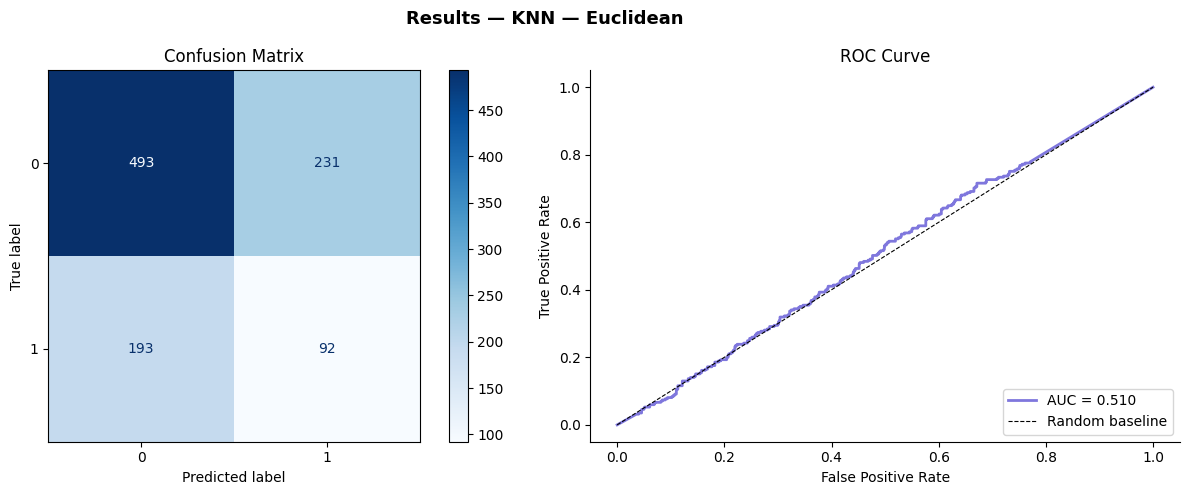

              precision    recall  f1-score   support

     Class 0       0.72      0.68      0.70       724
     Class 1       0.28      0.32      0.30       285

    accuracy                           0.58      1009
   macro avg       0.50      0.50      0.50      1009
weighted avg       0.60      0.58      0.59      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 493
    FP (false positives)   : 231
    FN (false negatives)   : 193
    TP (correct positives) : 92
    AUC                    : 0.5096


In [28]:
print_classification_results(
    best_model = random_search.best_estimator_,
    X_test     = X_test,
    y_test     = y_test,
    model_name = "KNN — Euclidean"
)

## DTW 

In [20]:
random_state = 42

param_list = {
    'n_neighbors': [4, 8, 16, 32, 64, 128],
    'weights': ['uniform', 'distance'],
    "distance"    : ["dtw"],
    "distance_params": [
        {"window": 0.05},   # very tight band — 10 steps
        {"window": 0.10},   # standard recommendation — 20 steps
        {"window": 0.20},   # looser — 40 steps
    ],
    "n_jobs": [-1]
}

random_search_dtw = RandomizedSearchCV(
    KNeighborsTimeSeriesClassifier(),
    param_distributions = param_list,
    cv                  = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring             = "f1_macro",
    n_jobs              = -1,
    refit               = True,
    n_iter              = 10,        
    random_state        = random_state
)

random_search_dtw.fit(X_train, y_train)


,estimator,KNeighborsTim...esClassifier()
,param_distributions,"{'distance': ['dtw'], 'distance_params': [{'window': 0.05}, {'window': 0.1}, ...], 'n_jobs': [-1], 'n_neighbors': [4, 8, ...], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
print(f"Best params : {random_search_dtw.best_params_}")
print(f"Best CV f1  : {random_search_dtw.best_score_:.4f}")

Best params : {'weights': 'distance', 'n_neighbors': 4, 'n_jobs': -1, 'distance_params': {'window': 0.1}, 'distance': 'dtw'}
Best CV f1  : 0.5811


  Model       : KNN DTW
  Test F1     : 0.5844


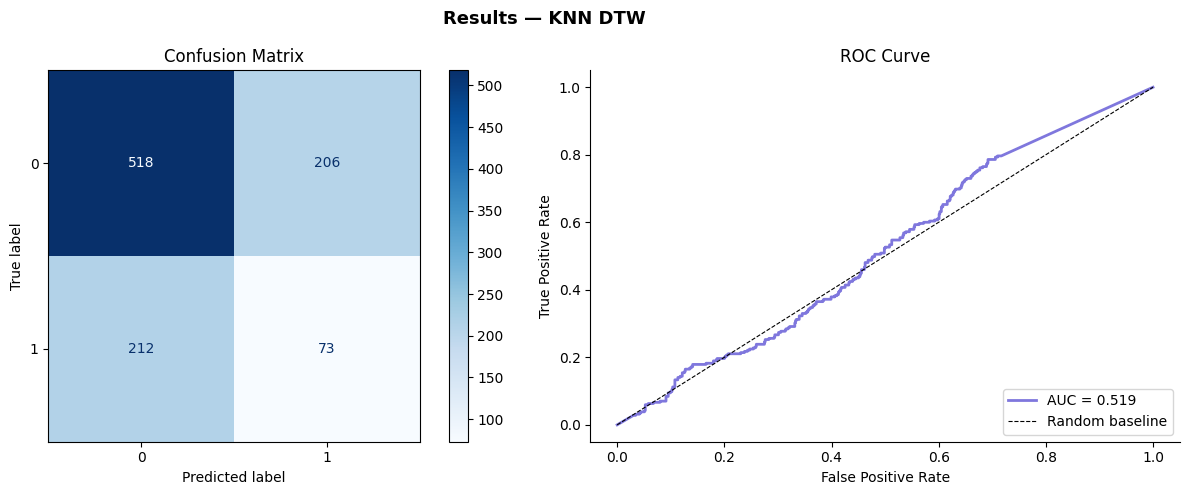

              precision    recall  f1-score   support

     Class 0       0.71      0.72      0.71       724
     Class 1       0.26      0.26      0.26       285

    accuracy                           0.59      1009
   macro avg       0.49      0.49      0.49      1009
weighted avg       0.58      0.59      0.58      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 518
    FP (false positives)   : 206
    FN (false negatives)   : 212
    TP (correct positives) : 73
    AUC                    : 0.5186


In [23]:
print_classification_results(
    best_model  = random_search_dtw.best_estimator_,
    X_test      = X_test,
    y_test      = y_test,
    model_name  = "KNN DTW"
)

# SHAPELETS

## convert df in 3d df

In [24]:
# Drop unwanted channels. they carry no information for shapelets
cols_to_drop = ["weekday", "non-wear_flag"] 

X_train_filtered = X_train.drop(columns=cols_to_drop)
X_test_filtered  = X_test.drop(columns=cols_to_drop)

print(f"Remaining channels: {list(X_train_filtered.columns)}")  # → 6 channels

# Convert to 3D numpy array
X_train_3d = np.stack([
    np.stack(X_train_filtered.iloc[i].values)
    for i in range(len(X_train_filtered))
])  # → (n_samples, 6, 200)

X_test_3d = np.stack([
    np.stack(X_test_filtered.iloc[i].values)
    for i in range(len(X_test_filtered))
])

print(f"X_train_3d: {X_train_3d.shape}")  # → (3298, 6, 200)
print(f"X_test_3d:  {X_test_3d.shape}")   # → (1009, 6, 200)
print(type(X_train_3d))

Remaining channels: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
X_train_3d: (3298, 6, 200)
X_test_3d:  (1009, 6, 200)
<class 'numpy.ndarray'>


## shapelets fit and transform (multivariate case)

In [27]:
from aeon.transformations.collection.shapelet_based import RandomShapeletTransform
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np

rst = RandomShapeletTransform(
    n_shapelet_samples=1000,   # How many candidate shapelets to evaluate during search
    max_shapelets=200,         # Max shapelets kept after filtering (become features)
    min_shapelet_length=4,     # Shortest subsequence to consider
    max_shapelet_length=30,    # Longest subsequence to consider
    n_jobs=-1,
    # In multivariate mode, shapelets are extracted from ONE channel at a time.
    # The transform records BOTH the best distance AND which channel it came from.
)

In [28]:
%%time
rst.fit(X_train_3d, y_train)
# ↑ Searches across all channels for the most discriminative subsequences.
#   With n_channels > 1, the search space is n_channels × n_timepoints wide.

CPU times: total: 32.1 s
Wall time: 32.2 s


,n_shapelet_samples,1000
,max_shapelets,200
,min_shapelet_length,4
,max_shapelet_length,30
,remove_self_similar,True
,batch_size,100
,verbose,False
,time_limit_in_minutes,0.0
,contract_max_n_shapelet_samples,inf
,n_jobs,-1
,parallel_backend,None


In [29]:
%%time
shapelets_distances_train = rst.transform(X_train_3d)
shapelets_distances_test  = rst.transform(X_test_3d)

# Output shape: (n_samples, max_shapelets) for BOTH uni- and multivariate
# Each column = min distance from that sample to one discovered shapelet
print(shapelets_distances_train.shape)  # e.g. (8000, 200)
print(shapelets_distances_test.shape)   # e.g. (2000, 200)

(3298, 200)
(1009, 200)
CPU times: total: 1min 17s
Wall time: 1min 20s


In [30]:
# Saving everything 
np.save('../1.DATASET/shapelets.npy', np.array(rst.shapelets, dtype=object))
# 
np.save('../1.DATASET/shapelets_distances_train.npy', shapelets_distances_train)
np.save('../1.DATASET/shapelets_distances_test.npy', shapelets_distances_test)

In [31]:
from collections import Counter

# Channels actually used by the shapelet transform
filtered_signals = list(X_train_filtered.columns)

# How many shapelets were found
print(f"Total shapelets: {len(rst.shapelets)}")

# Inspect the first shapelet
ig, length, start, channel, instance_idx, class_val, values = rst.shapelets[0]

print(f"Info gain  : {ig:.4f}")
print(f"Length     : {length}")
print(f"Start pos  : {start}")
print(f"Channel    : {channel} → {filtered_signals[channel]}")
print(f"From sample: {instance_idx} (class {class_val})")
print(f"Values     : {values}")

# Count shapelets by channel
channel_counts = Counter(s[3] for s in rst.shapelets)

print("\nShapelets per channel:")
for ch, count in sorted(channel_counts.items()):
    print(f"  Channel {ch} ({filtered_signals[ch]}): {count} shapelets")

Total shapelets: 200
Info gain  : 0.0735
Length     : 4
Start pos  : 89
Channel    : 5 → light
From sample: 145 (class 1)
Values     : [0. 0. 0. 0.]

Shapelets per channel:
  Channel 0 (X): 28 shapelets
  Channel 1 (Y): 13 shapelets
  Channel 2 (Z): 13 shapelets
  Channel 3 (enmo): 33 shapelets
  Channel 4 (anglez): 34 shapelets
  Channel 5 (light): 79 shapelets


## train DT on shapelets dataset

In [34]:

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [8, 16, 32, 64, 128, 256, 512] + [None],
    'min_samples_split': [4, 8, 16, 32, 64, 128, 256],
    'min_samples_leaf': [4, 8, 16, 32, 64, 128, 256],
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced'),
    param_distributions=param_dist,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state),
    scoring='f1_macro', 
    refit=True,
    verbose=1,
    n_iter=50,
    random_state=42
)

rand_search.fit(shapelets_distances_train, y_train)
dec_tree = rand_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [35]:
y_pred = rand_search.predict(shapelets_distances_test)

print("Best params  :", rand_search.best_params_)
print("Best CV f1   :", round(rand_search.best_score_, 4))

Best params  : {'min_samples_split': 64, 'min_samples_leaf': 128, 'max_depth': 128, 'criterion': 'gini'}
Best CV f1   : 0.5398


  Model       : Shapelet + Decision Tree
  Test F1     : 0.5134


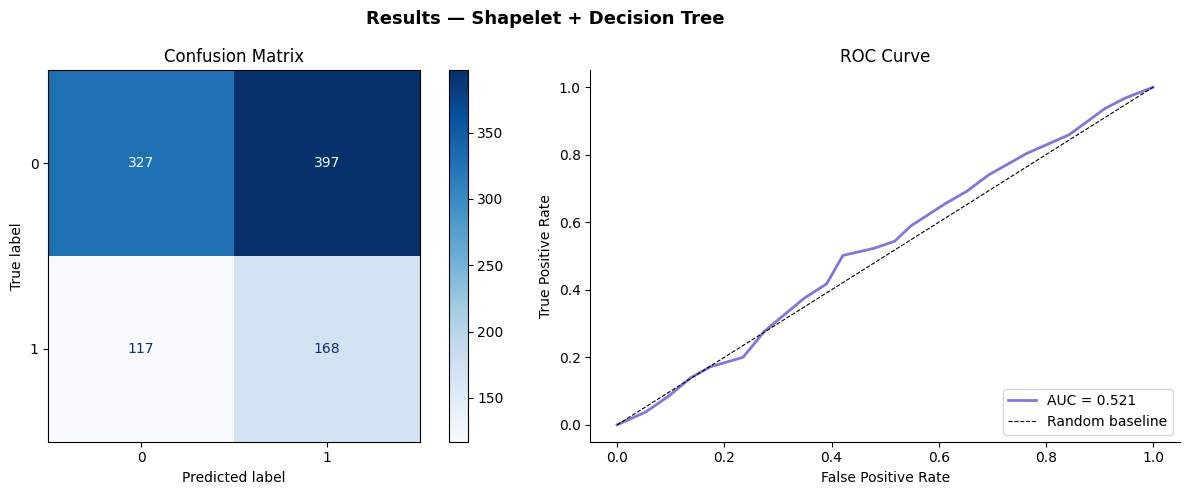

              precision    recall  f1-score   support

     Class 0       0.74      0.45      0.56       724
     Class 1       0.30      0.59      0.40       285

    accuracy                           0.49      1009
   macro avg       0.52      0.52      0.48      1009
weighted avg       0.61      0.49      0.51      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 327
    FP (false positives)   : 397
    FN (false negatives)   : 117
    TP (correct positives) : 168
    AUC                    : 0.5210


In [36]:
print_classification_results(
    best_model  = dec_tree,                   # best estimator from grid_search
    X_test      = shapelets_distances_test,   # ← distance matrix, NOT raw 3D array
    y_test      = y_test,
    model_name  = "Shapelet + Decision Tree"
)

# MINIROCKET

In [37]:
from sktime.classification.kernel_based import RocketClassifier

In [41]:
param_distributions = {
    "rocket_transform": ["minirocket"], 
    "num_kernels": [1000, 2000, 4000, 6000, 8000, 10000],
    "max_dilations_per_kernel": [4, 8, 16, 32, 64],
    "n_jobs": [-1], # Ensure the underlying transformer uses all cores
}

random_search = RandomizedSearchCV(
    estimator=RocketClassifier(),
    param_distributions=param_distributions,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_iter=10,     
    scoring="f1_macro",
    refit=True,
    random_state=42
)
random_search.fit(X_train, y_train)
best_rocket = random_search.best_estimator_

In [42]:

print(f"Best params : {random_search.best_params_}")
print(f"Best CV f1  : {random_search.best_score_:.4f}")

Best params : {'rocket_transform': 'minirocket', 'num_kernels': 8000, 'n_jobs': -1, 'max_dilations_per_kernel': 64}
Best CV f1  : 0.6256


  Model       : ROCKET — Randomized Multivariate
  Test F1     : 0.6281


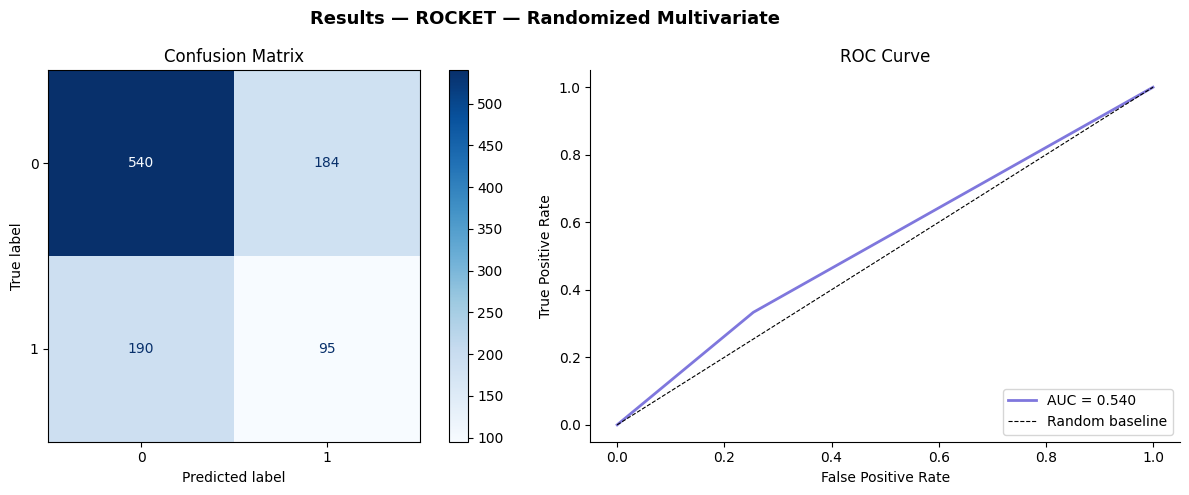

              precision    recall  f1-score   support

     Class 0       0.74      0.75      0.74       724
     Class 1       0.34      0.33      0.34       285

    accuracy                           0.63      1009
   macro avg       0.54      0.54      0.54      1009
weighted avg       0.63      0.63      0.63      1009

  Confusion Matrix breakdown:
    TN (correct negatives) : 540
    FP (false positives)   : 184
    FN (false negatives)   : 190
    TP (correct positives) : 95
    AUC                    : 0.5396


In [43]:
print_classification_results(
    best_model=best_rocket,
    X_test=X_test,
    y_test=y_test,
    model_name="ROCKET — Randomized Multivariate"
)